# Projet Machine Learning — Classification des Maladies Cardiaques


## 1. Importation des Bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn : prétraitement
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Scikit-learn : modèles
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Scikit-learn : métriques
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Reproductibilité
SEED = 42
np.random.seed(SEED)

print("✅ Bibliothèques importées avec succès")

✅ Bibliothèques importées avec succès


---
## 2. Chargement et Exploration du Dataset

In [2]:
# Chargement du dataset (UCI Heart Disease — version consolidée)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv')
print(f"✅ Dataset chargé — {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head()

✅ Dataset chargé — 920 lignes × 16 colonnes


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
# ── Uniformisation des noms de colonnes ──────────────────────────────────────
df.columns = [c.lower().strip() for c in df.columns]

# Description des colonnes connues du dataset UCI
col_descriptions = {
    'age'     : 'Âge du patient (années)',
    'sex'     : 'Sexe (1 = homme, 0 = femme)',
    'cp'      : 'Type de douleur thoracique (0–3)',
    'trestbps': 'Tension artérielle au repos (mm Hg)',
    'chol'    : 'Cholestérol sérique (mg/dl)',
    'fbs'     : 'Glycémie à jeun > 120 mg/dl (1 = vrai)',
    'restecg' : 'Résultats ECG au repos (0–2)',
    'thalch'  : 'Fréquence cardiaque maximale atteinte',
    'exang'   : 'Angine induite par effort (1 = oui)',
    'oldpeak' : 'Dépression ST induite par effort',
    'slope'   : 'Pente du segment ST en effort',
    'ca'      : 'Nombre de vaisseaux colorés (0–3)',
    'thal'    : 'Thalassémie (normal / fixe / réversible)',
    'num'     : 'Diagnostic (0 = sain, >0 = maladie)',
    'target'  : 'Cible binaire (0 = sain, 1 = malade)',
}
print("📋 Description des variables disponibles :")
for c in df.columns:
    print(f"  {c:12s} → {col_descriptions.get(c, 'variable présente')}")

📋 Description des variables disponibles :
  id           → variable présente
  age          → Âge du patient (années)
  sex          → Sexe (1 = homme, 0 = femme)
  dataset      → variable présente
  cp           → Type de douleur thoracique (0–3)
  trestbps     → Tension artérielle au repos (mm Hg)
  chol         → Cholestérol sérique (mg/dl)
  fbs          → Glycémie à jeun > 120 mg/dl (1 = vrai)
  restecg      → Résultats ECG au repos (0–2)
  thalch       → Fréquence cardiaque maximale atteinte
  exang        → Angine induite par effort (1 = oui)
  oldpeak      → Dépression ST induite par effort
  slope        → Pente du segment ST en effort
  ca           → Nombre de vaisseaux colorés (0–3)
  thal         → Thalassémie (normal / fixe / réversible)
  num          → Diagnostic (0 = sain, >0 = maladie)


In [5]:
# ── Construction de la cible binaire ─────────────────────────────────────────
if 'num' in df.columns and 'target' not in df.columns:
    df['target'] = (df['num'] > 0).astype(int)
    print("✅ Colonne 'target' créée depuis 'num'")
elif 'target' in df.columns:
    # Assurer que target est numérique 0/1
    if df['target'].dtype == object:
        df['target'] = (df['target'] != '0').astype(int)
    else:
        df['target'] = (df['target'] > 0).astype(int)
    print("✅ Colonne 'target' normalisée")

print(f"\n📊 Distribution de la cible :")
print(df['target'].value_counts())
print(f"   Proportion maladies : {df['target'].mean()*100:.1f}%")

✅ Colonne 'target' créée depuis 'num'

📊 Distribution de la cible :
target
1    509
0    411
Name: count, dtype: int64
   Proportion maladies : 55.3%


In [6]:
# ── Aperçu général du dataset ────────────────────────────────────────────────
print("=" * 55)
print("APERÇU GÉNÉRAL DU DATASET")
print("=" * 55)
print(f"Dimensions      : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Valeurs nulles  : {df.isnull().sum().sum()} au total")
print(f"Doublons        : {df.duplicated().sum()}")
print("\nTypes de données :")
print(df.dtypes.value_counts())
print("\nStatistiques descriptives :")
df.describe()

APERÇU GÉNÉRAL DU DATASET
Dimensions      : 920 lignes × 17 colonnes
Valeurs nulles  : 1759 au total
Doublons        : 0

Types de données :
object     8
float64    5
int64      4
Name: count, dtype: int64

Statistiques descriptives :


,id,age,trestbps,chol,thalch,oldpeak,ca,num,target
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652,0.553261
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693,0.497426
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000,1.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000,1.000000


In [7]:
# ── Valeurs manquantes par colonne ───────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': missing_pct})
missing_df = missing_df[missing_df['Manquants'] > 0].sort_values('Pourcentage (%)', ascending=False)

if missing_df.empty:
    print("✅ Aucune valeur manquante détectée.")
else:
    print("⚠️  Valeurs manquantes détectées :")
    display(missing_df)

⚠️  Valeurs manquantes détectées :


,Manquants,Pourcentage (%)
ca,611,66.41
thal,486,52.83
slope,309,33.59
fbs,90,9.78
oldpeak,62,6.74
trestbps,59,6.41
exang,55,5.98
thalch,55,5.98
chol,30,3.26
restecg,2,0.22


---
## 3. Analyse Exploratoire des Données (EDA)

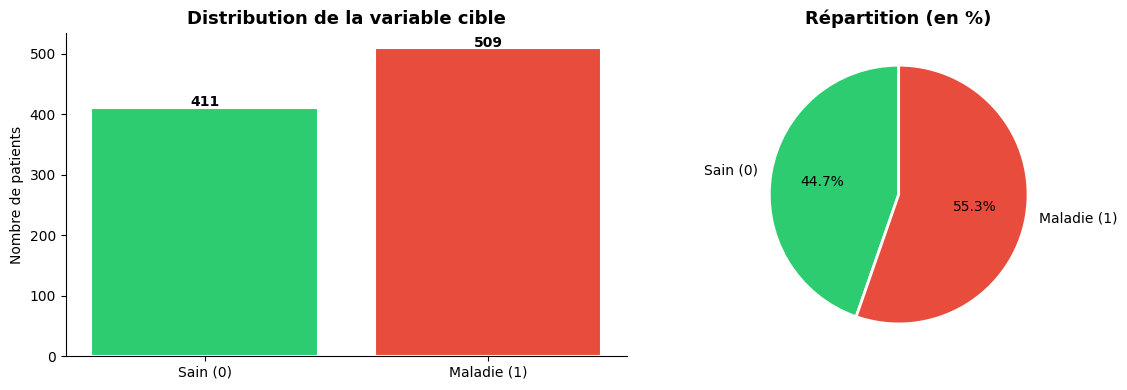

Figure sauvegardée.


In [8]:
# ── 3.1 Distribution de la variable cible ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#2ecc71', '#e74c3c']
labels = ['Sain (0)', 'Maladie (1)']
vals = df['target'].value_counts().sort_index()

# Barplot
axes[0].bar(labels, vals, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution de la variable cible', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de patients')
for i, v in enumerate(vals):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Pie chart
axes[1].pie(vals, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Répartition (en %)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/fig_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée.")

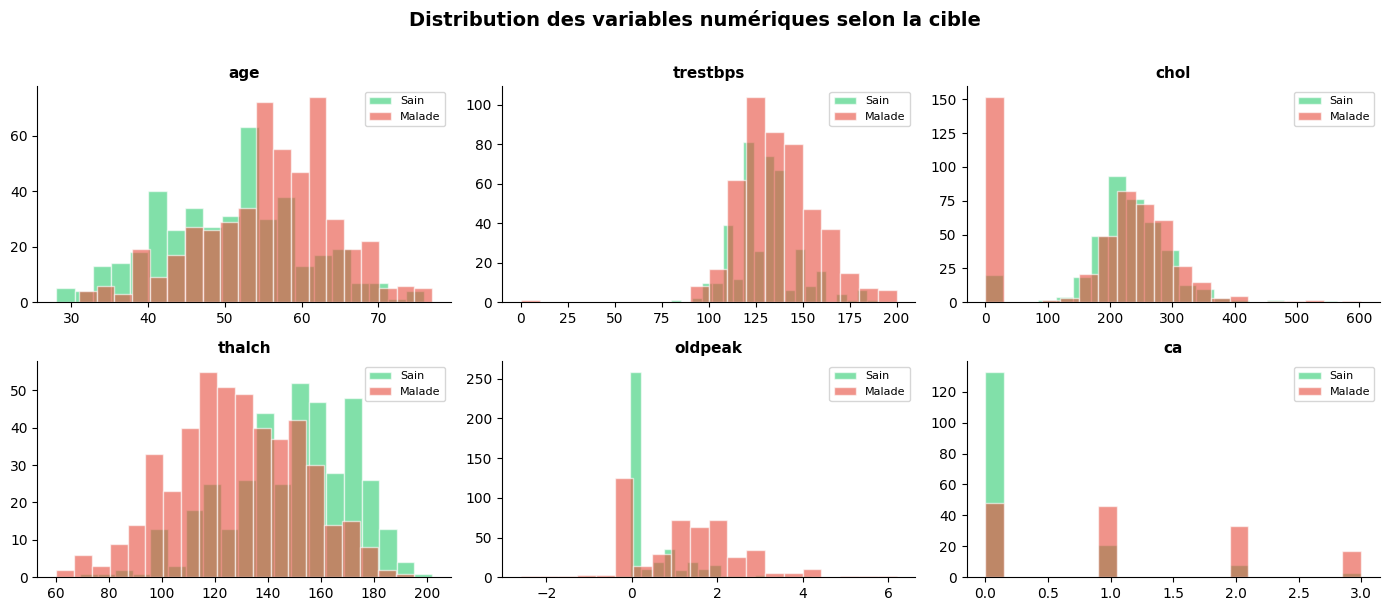

In [9]:
# ── 3.2 Distribution des features numériques ─────────────────────────────────
# Identification des colonnes numériques (hors target et 'num')
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['target', 'num', 'id']]

n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for t, color, label in [(0, '#2ecc71', 'Sain'), (1, '#e74c3c', 'Malade')]:
        subset = df[df['target'] == t][col].dropna()
        ax.hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Masquer les axes vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des variables numériques selon la cible', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_target.png', dpi=150, bbox_inches='tight')
plt.show()

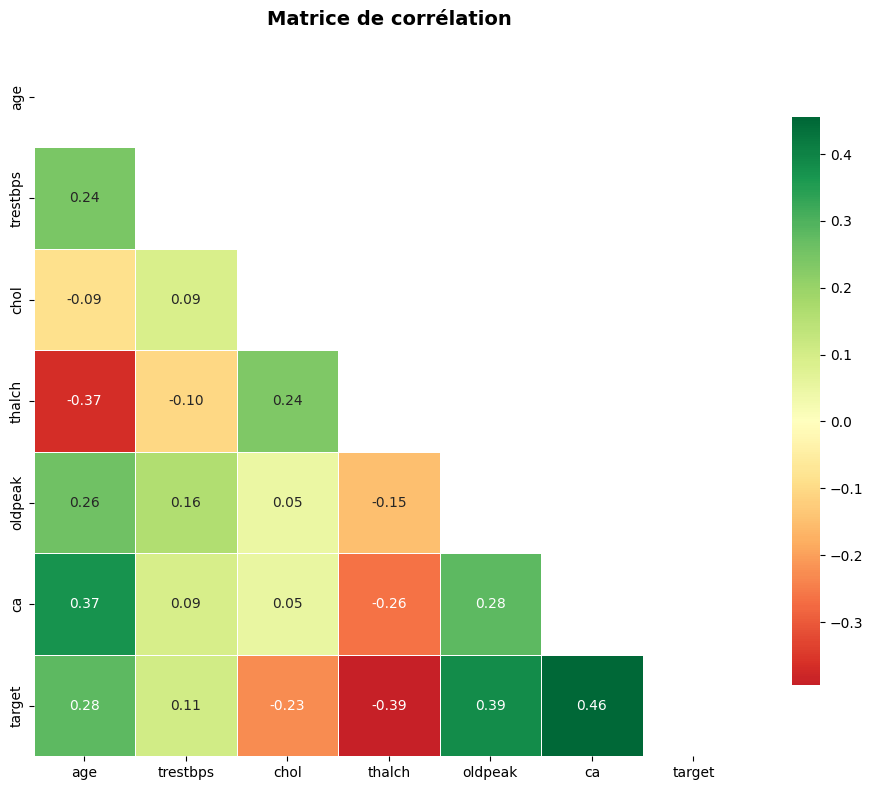


📊 Corrélations avec la cible (triées) :
ca          0.455599
thalch     -0.394503
oldpeak     0.385528
age         0.282700
chol       -0.230583
trestbps    0.106233


In [10]:
# ── 3.3 Matrice de corrélation ────────────────────────────────────────────────
num_df = df[num_cols + ['target']].copy()
# Convertir en numérique si nécessaire
for c in num_df.columns:
    num_df[c] = pd.to_numeric(num_df[c], errors='coerce')

corr = num_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de corrélation', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_target.png', dpi=150, bbox_inches='tight')
plt.show()

# Corrélations avec la cible
print("\n📊 Corrélations avec la cible (triées) :")
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
print(target_corr.to_string())

---
## 4. Préparation des Données

In [11]:
# ── 4.1 Sélection des features ────────────────────────────────────────────────
# Exclure la cible, l'identifiant, et la variable 'num' (source de la cible)
exclude = ['target', 'num', 'id']
feature_cols = [c for c in df.columns if c not in exclude]

X = df[feature_cols].copy()
y = df['target'].copy()

print(f"Features sélectionnées ({len(feature_cols)}) : {feature_cols}")
print(f"Taille X : {X.shape}, taille y : {y.shape}")

# ── Identification des types de colonnes ─────────────────────────────────────
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_feature_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nVariables numériques ({len(num_feature_cols)}) : {num_feature_cols}")
print(f"Variables catégorielles ({len(cat_cols)}) : {cat_cols}")

Features sélectionnées (14) : ['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Taille X : (920, 14), taille y : (920,)

Variables numériques (6) : ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Variables catégorielles (8) : ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [12]:
# ── 4.2 Split Train / Test ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train : {X_train.shape[0]} échantillons")
print(f"Test  : {X_test.shape[0]} échantillons")
print(f"\nDistribution cible (train) : {y_train.value_counts().to_dict()}")
print(f"Distribution cible (test)  : {y_test.value_counts().to_dict()}")

Train : 736 échantillons
Test  : 184 échantillons

Distribution cible (train) : {1: 407, 0: 329}
Distribution cible (test)  : {1: 102, 0: 82}


In [13]:
# ── 4.3 Définition du préprocesseur via ColumnTransformer ────────────────────

# Pipeline numérique : imputation médiane + normalisation
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline catégoriel : imputation mode + encodage one-hot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Assemblage
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_feature_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')

print("✅ Préprocesseur défini :")
print(f"   - Numérique  : imputation médiane + StandardScaler ({len(num_feature_cols)} features)")
print(f"   - Catégoriel : imputation mode + OneHotEncoder ({len(cat_cols)} features)")

✅ Préprocesseur défini :
   - Numérique  : imputation médiane + StandardScaler (6 features)
   - Catégoriel : imputation mode + OneHotEncoder (8 features)


---
## 5. Construction des Pipelines

In [14]:
# ── 5.1 Définition des modèles et de leurs grilles d'hyperparamètres ─────────

models_config = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=SEED, max_iter=1000),
        'params': {
            'classifier__C': [0.01, 0.1, 1, 10, 100],
            'classifier__solver': ['lbfgs', 'liblinear'],
            'classifier__penalty': ['l2'],
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=SEED),
        'params': {
            'classifier__max_depth': [3, 5, 7, 10, None],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__criterion': ['gini', 'entropy'],
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=SEED),
        'params': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [5, 10, None],
            'classifier__min_samples_split': [2, 5],
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=SEED),
        'params': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__learning_rate': [0.05, 0.1, 0.2],
            'classifier__max_depth': [3, 5],
        }
    },
    'SVM': {
        'model': SVC(random_state=SEED, probability=True),
        'params': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear'],
            'classifier__gamma': ['scale', 'auto'],
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'classifier__n_neighbors': [3, 5, 7, 9, 11],
            'classifier__weights': ['uniform', 'distance'],
            'classifier__metric': ['euclidean', 'manhattan'],
        }
    },
}

print(f"✅ {len(models_config)} modèles configurés :")
for name, cfg in models_config.items():
    n_combinations = 1
    for v in cfg['params'].values():
        n_combinations *= len(v)
    print(f"   - {name:25s}: {n_combinations} combinaisons d'hyperparamètres")

✅ 6 modèles configurés :
   - Logistic Regression      : 10 combinaisons d'hyperparamètres
   - Decision Tree            : 30 combinaisons d'hyperparamètres
   - Random Forest            : 18 combinaisons d'hyperparamètres
   - Gradient Boosting        : 18 combinaisons d'hyperparamètres
   - SVM                      : 12 combinaisons d'hyperparamètres
   - KNN                      : 20 combinaisons d'hyperparamètres


In [15]:
# ── 5.2 Entraînement avec GridSearchCV ────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results = {}

for name, config in models_config.items():
    print(f"\n⏳ [{name}] GridSearch en cours...")
    
    # Construction du pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', config['model'])
    ])
    
    # GridSearchCV
    grid_search = GridSearchCV(
        pipeline,
        param_grid=config['params'],
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train, y_train)
    
    # Évaluation sur le test set
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cv_score = grid_search.best_score_
    
    results[name] = {
        'grid_search': grid_search,
        'best_model': best_model,
        'best_params': grid_search.best_params_,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': acc,
        'roc_auc': auc,
        'cv_roc_auc': cv_score,
    }
    
    print(f"   ✅ CV AUC = {cv_score:.4f} | Test Acc = {acc:.4f} | Test AUC = {auc:.4f}")
    print(f"   Meilleurs params : {grid_search.best_params_}")

print("\n🎉 Tous les modèles entraînés !")


⏳ [Logistic Regression] GridSearch en cours...
   ✅ CV AUC = 0.9006 | Test Acc = 0.8370 | Test AUC = 0.9204
   Meilleurs params : {'classifier__C': 1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

⏳ [Decision Tree] GridSearch en cours...
   ✅ CV AUC = 0.8043 | Test Acc = 0.8043 | Test AUC = 0.8683
   Meilleurs params : {'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_split': 2}

⏳ [Random Forest] GridSearch en cours...
   ✅ CV AUC = 0.8916 | Test Acc = 0.8696 | Test AUC = 0.9269
   Meilleurs params : {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}

⏳ [Gradient Boosting] GridSearch en cours...
   ✅ CV AUC = 0.8799 | Test Acc = 0.8750 | Test AUC = 0.9297
   Meilleurs params : {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}

⏳ [SVM] GridSearch en cours...
   ✅ CV AUC = 0.8987 | Test Acc = 0.8478 | Test AUC = 0.9225
   Meilleurs params : {'c

---
## 6. Évaluation et Comparaison des Modèles

In [16]:
# ── 6.1 Tableau récapitulatif ─────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

summary_rows = []
for name, res in results.items():
    prec = precision_score(y_test, res['y_pred'])
    rec  = recall_score(y_test, res['y_pred'])
    f1   = f1_score(y_test, res['y_pred'])
    summary_rows.append({
        'Modèle': name,
        'CV AUC (5-fold)': round(res['cv_roc_auc'], 4),
        'Test Accuracy': round(res['accuracy'], 4),
        'Test ROC-AUC': round(res['roc_auc'], 4),
        'Précision': round(prec, 4),
        'Rappel': round(rec, 4),
        'F1-Score': round(f1, 4),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Test ROC-AUC', ascending=False)
summary_df = summary_df.reset_index(drop=True)
print("📊 Tableau comparatif des modèles (trié par ROC-AUC décroissant) :")
display(summary_df)

📊 Tableau comparatif des modèles (trié par ROC-AUC décroissant) :


,Modèle,CV AUC (5-fold),Test Accuracy,Test ROC-AUC,Précision,Rappel,F1-Score
0,Gradient Boosting,0.8799,0.8750,0.9297,0.8624,0.9216,0.8910
1,Random Forest,0.8916,0.8696,0.9269,0.8611,0.9118,0.8857
2,SVM,0.8987,0.8478,0.9225,0.8246,0.9216,0.8704
3,Logistic Regression,0.9006,0.8370,0.9204,0.8273,0.8922,0.8585
4,KNN,0.8982,0.8587,0.9171,0.8585,0.8922,0.8750
5,Decision Tree,0.8043,0.8043,0.8683,0.8837,0.7451,0.8085


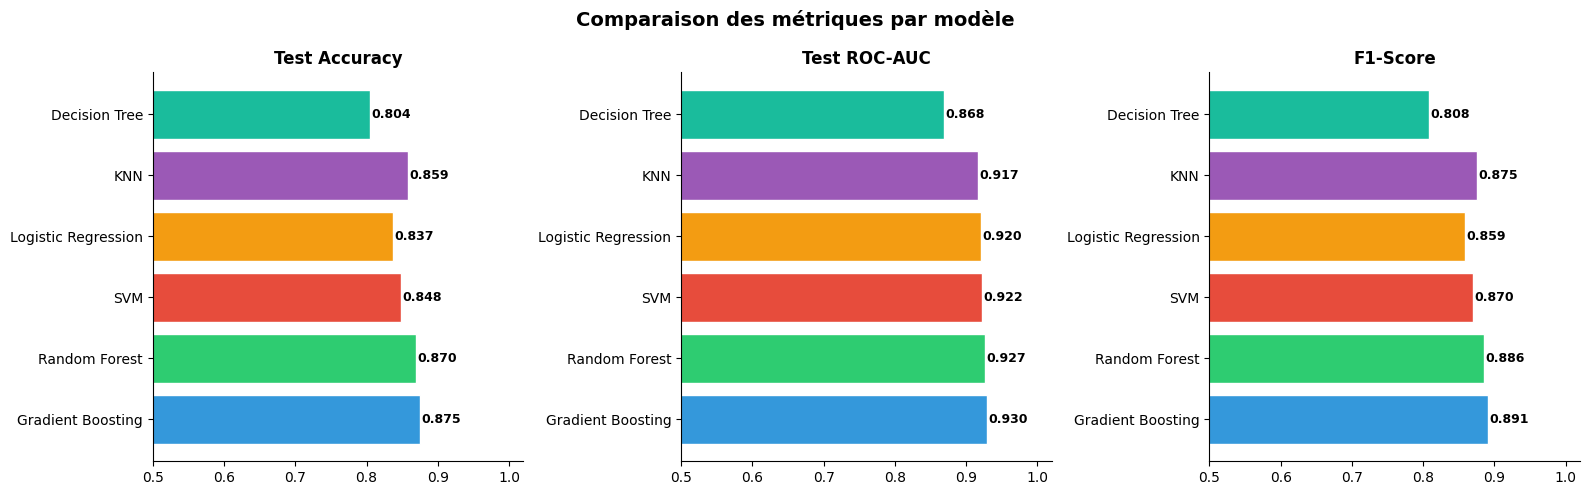

In [17]:
# ── 6.2 Visualisation comparative ────────────────────────────────────────────
metrics_to_plot = ['Test Accuracy', 'Test ROC-AUC', 'F1-Score']
model_names = summary_df['Modèle'].tolist()
palette = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, metric in enumerate(metrics_to_plot):
    vals = summary_df[metric].values
    bars = axes[i].barh(model_names, vals, color=palette[:len(model_names)], edgecolor='white')
    axes[i].set_xlim(0.5, 1.02)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    for bar, val in zip(bars, vals):
        axes[i].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparaison des métriques par modèle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/fig_target.png', dpi=150, bbox_inches='tight')
plt.show()

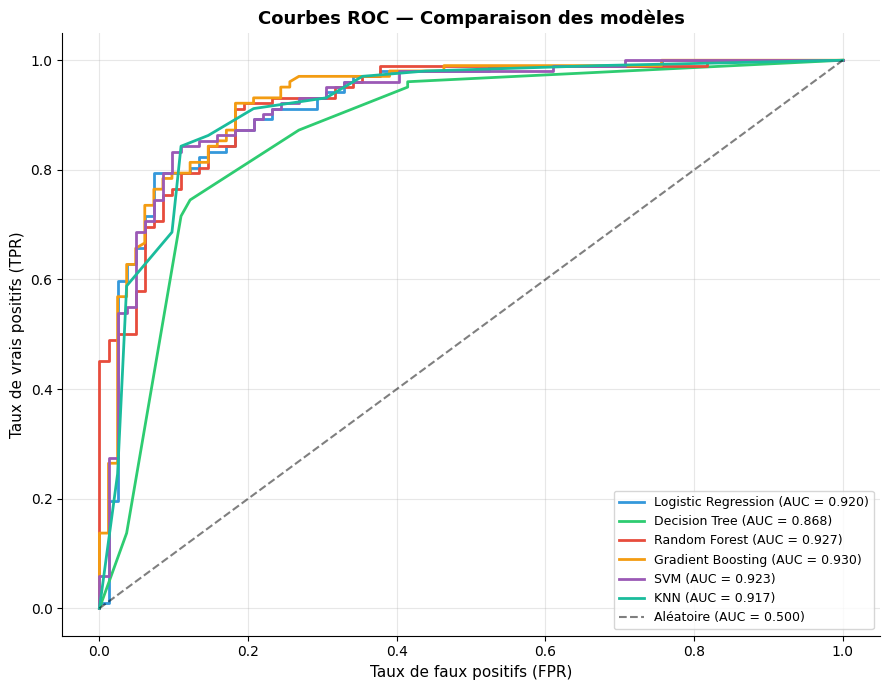

In [18]:
# ── 6.3 Courbes ROC ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for (name, res), color in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{name} (AUC = {res['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Aléatoire (AUC = 0.500)')
ax.set_xlabel('Taux de faux positifs (FPR)', fontsize=11)
ax.set_ylabel('Taux de vrais positifs (TPR)', fontsize=11)
ax.set_title('Courbes ROC — Comparaison des modèles', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_target.png', dpi=150, bbox_inches='tight')
plt.show()

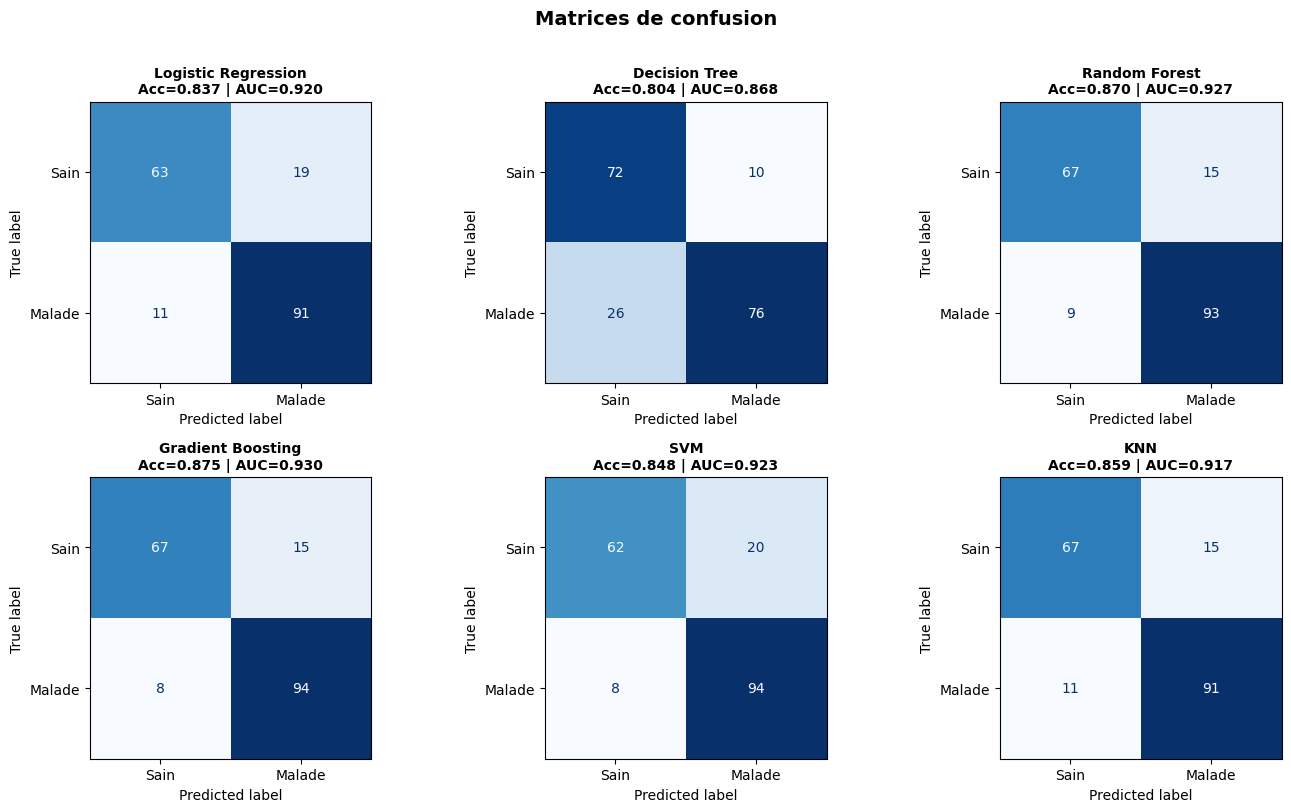

In [19]:
# ── 6.4 Matrices de confusion ────────────────────────────────────────────────
n_models = len(results)
ncols = 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sain', 'Malade'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAcc={res["accuracy"]:.3f} | AUC={res["roc_auc"]:.3f}',
                      fontsize=10, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Matrices de confusion', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_target.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Analyse du Modèle Optimal

In [20]:
# ── 7.1 Identification du meilleur modèle ─────────────────────────────────────
best_name = summary_df.iloc[0]['Modèle']
best_res = results[best_name]

print("=" * 55)
print(f"🏆 MODÈLE OPTIMAL : {best_name}")
print("=" * 55)
print(f"   CV AUC (5-fold) : {best_res['cv_roc_auc']:.4f}")
print(f"   Test Accuracy   : {best_res['accuracy']:.4f}")
print(f"   Test ROC-AUC    : {best_res['roc_auc']:.4f}")
print(f"\n   Meilleurs hyperparamètres :")
for k, v in best_res['best_params'].items():
    print(f"     {k} = {v}")

print(f"\n📋 Rapport de classification détaillé :")
print(classification_report(y_test, best_res['y_pred'], target_names=['Sain', 'Malade']))

🏆 MODÈLE OPTIMAL : Gradient Boosting
   CV AUC (5-fold) : 0.8799
   Test Accuracy   : 0.8750
   Test ROC-AUC    : 0.9297

   Meilleurs hyperparamètres :
     classifier__learning_rate = 0.1
     classifier__max_depth = 3
     classifier__n_estimators = 50

📋 Rapport de classification détaillé :
              precision    recall  f1-score   support

        Sain       0.89      0.82      0.85        82
      Malade       0.86      0.92      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.87       184



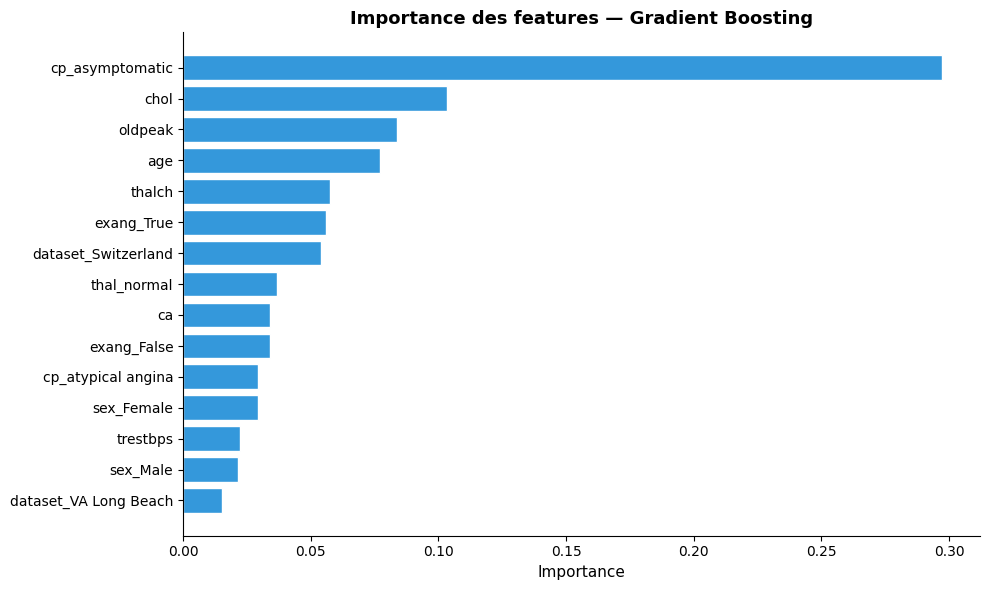

Figure sauvegardée.


In [21]:
# ── 7.2 Importance des features (si modèle basé sur des arbres) ───────────────
best_clf = best_res['best_model'].named_steps['classifier']
preprocessor_fitted = best_res['best_model'].named_steps['preprocessor']

if hasattr(best_clf, 'feature_importances_'):
    try:
        num_names = num_feature_cols
        if cat_cols:
            ohe = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
            cat_names = ohe.get_feature_names_out(cat_cols).tolist()
        else:
            cat_names = []
        all_feature_names = num_names + cat_names
    except:
        all_feature_names = [f'feature_{i}' for i in range(len(best_clf.feature_importances_))]

    importances = best_clf.feature_importances_
    n_feat = min(len(importances), len(all_feature_names))
    indices = np.argsort(importances[:n_feat])[::-1][:15]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh([all_feature_names[i] for i in indices[::-1]],
            importances[indices[::-1]],
            color='#3498db', edgecolor='white')
    ax.set_xlabel('Importance', fontsize=11)
    ax.set_title(f'Importance des features — {best_name}', fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('/kaggle/working/fig_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

elif hasattr(best_clf, 'coef_'):
    coef = best_clf.coef_[0]
    try:
        num_names = num_feature_cols
        if cat_cols:
            ohe = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
            cat_names = ohe.get_feature_names_out(cat_cols).tolist()
        else:
            cat_names = []
        all_feature_names = num_names + cat_names
    except:
        all_feature_names = [f'feature_{i}' for i in range(len(coef))]

    n_feat = min(len(coef), len(all_feature_names))
    coef_sorted_idx = np.argsort(np.abs(coef[:n_feat]))[::-1][:15]

    fig, ax = plt.subplots(figsize=(10, 6))
    colors_coef = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef[coef_sorted_idx[::-1]]]
    ax.barh([all_feature_names[i] for i in coef_sorted_idx[::-1]],
            coef[coef_sorted_idx[::-1]], color=colors_coef, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Coefficient', fontsize=11)
    ax.set_title(f'Coefficients — {best_name} (rouge = ↑ risque)', fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('/kaggle/working/fig_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

else:
    print(f"ℹ️  L'importance des features n'est pas directement disponible pour {best_name}.")

print("Figure sauvegardée.")

---
## 8. Interprétation et Conclusion

In [22]:
# ── Résumé final ──────────────────────────────────────────────────────────────
print("=" * 65)
print("RÉSUMÉ FINAL — PROJET MACHINE LEARNING")
print("=" * 65)

print("\n📌 Problème : Classification binaire (maladie cardiaque)")
print(f"📌 Dataset  : Heart Disease UCI ({df.shape[0]} patients, {len(feature_cols)} features)")
print("📌 Méthode  : Pipelines scikit-learn + GridSearchCV (5-fold StratifiedCV)")

print("\n📊 Résultats par modèle (trié par Test AUC) :")
print("-" * 65)
for _, row in summary_df.iterrows():
    marker = "🏆" if row['Modèle'] == best_name else "  "
    print(f"{marker} {row['Modèle']:25s} | Acc={row['Test Accuracy']:.3f} | AUC={row['Test ROC-AUC']:.3f} | F1={row['F1-Score']:.3f}")

print("\n" + "=" * 65)
print(f"🏆 PIPELINE OPTIMAL : {best_name}")
print("=" * 65)
print(f"\n   Ce modèle offre le meilleur équilibre entre :")
print(f"   - Précision de généralisation (CV AUC = {best_res['cv_roc_auc']:.4f})")
print(f"   - Performance sur données non vues (Test AUC = {best_res['roc_auc']:.4f})")
print(f"   - Robustesse aux hyperparamètres (GridSearchCV exhaustif)")

print("\n   Interprétation médicale :")
cm = confusion_matrix(y_test, best_res['y_pred'])
tn, fp, fn, tp = cm.ravel()
print(f"   - {tp} vrais positifs (malades correctement identifiés)")
print(f"   - {fp} faux positifs (sains identifiés comme malades)")
print(f"   - {fn} faux négatifs (malades non détectés — cas critiques)")
print(f"   - {tn} vrais négatifs (sains correctement identifiés)")
print(f"\n   Sensibilité (Rappel) = {tp/(tp+fn):.3f} → {tp/(tp+fn)*100:.1f}% des malades détectés")

RÉSUMÉ FINAL — PROJET MACHINE LEARNING

📌 Problème : Classification binaire (maladie cardiaque)
📌 Dataset  : Heart Disease UCI (920 patients, 14 features)
📌 Méthode  : Pipelines scikit-learn + GridSearchCV (5-fold StratifiedCV)

📊 Résultats par modèle (trié par Test AUC) :
-----------------------------------------------------------------
🏆 Gradient Boosting         | Acc=0.875 | AUC=0.930 | F1=0.891
   Random Forest             | Acc=0.870 | AUC=0.927 | F1=0.886
   SVM                       | Acc=0.848 | AUC=0.922 | F1=0.870
   Logistic Regression       | Acc=0.837 | AUC=0.920 | F1=0.859
   KNN                       | Acc=0.859 | AUC=0.917 | F1=0.875
   Decision Tree             | Acc=0.804 | AUC=0.868 | F1=0.808

🏆 PIPELINE OPTIMAL : Gradient Boosting

   Ce modèle offre le meilleur équilibre entre :
   - Précision de généralisation (CV AUC = 0.8799)
   - Performance sur données non vues (Test AUC = 0.9297)
   - Robustesse aux hyperparamètres (GridSearchCV exhaustif)

   Interprétatio